## TITANIC DATASET – STATISTICAL DATA PREPROCESSING REPORT

### 1.Introduction
#### The Titanic dataset contains passenger demographic and travel information used to predict survival outcomes. Since real-world data often contains inconsistencies, missing values, and outliers, preprocessing is required before applying machine learning techniques.

### 2.Objective
#### The objective of this project is to perform systematic statistical preprocessing on the Titanic dataset to transform raw data into a clean and model-ready format.

### 3.Steps Performed
#### *Import Libraries
#### *Load Dataset
#### *Basic Data Understanding
#### *Missing Value Analysis
#### *Remove Unnecessary Columns & Check Duplicates
#### *Outlier Detection & Treatment
#### *Encoding categorical variables
#### *Feature Scaling (Standarization)
#### *Correlation Analysis

## Statistical Preprocessing

### Step-1 : Import Libraries

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step-2 : Load Dataset

In [88]:
df = pd.read_csv(r"C:\Users\abhit\Downloads\titanic.csv")

In [89]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Step-3 : Basic Data Understanding

In [90]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [91]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [92]:
df.shape

(891, 12)

In [93]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Step-4 : Missing Value Analysis

In [95]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### **Handle Missing Values

In [96]:
## Age fill with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [97]:
## more than 50% null values then drop
df.drop(['Cabin'],axis=1,inplace=True)

In [98]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [99]:
## calculate mode because embarked is object
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [100]:
## use label encoding and fill null values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Embarked'] = le.fit_transform(df['Embarked'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,2


### Step-5 : Remove Unnecessary Columns & Check Duplicates

In [102]:
df.drop(columns=['PassengerId','Name','Ticket'], inplace=True)

In [103]:
df.duplicated().sum()

111

In [104]:
df.drop_duplicates(inplace=True)

### Step 6: Outlier Detection & Treatment

#### 6.1) Boxplot Visualization

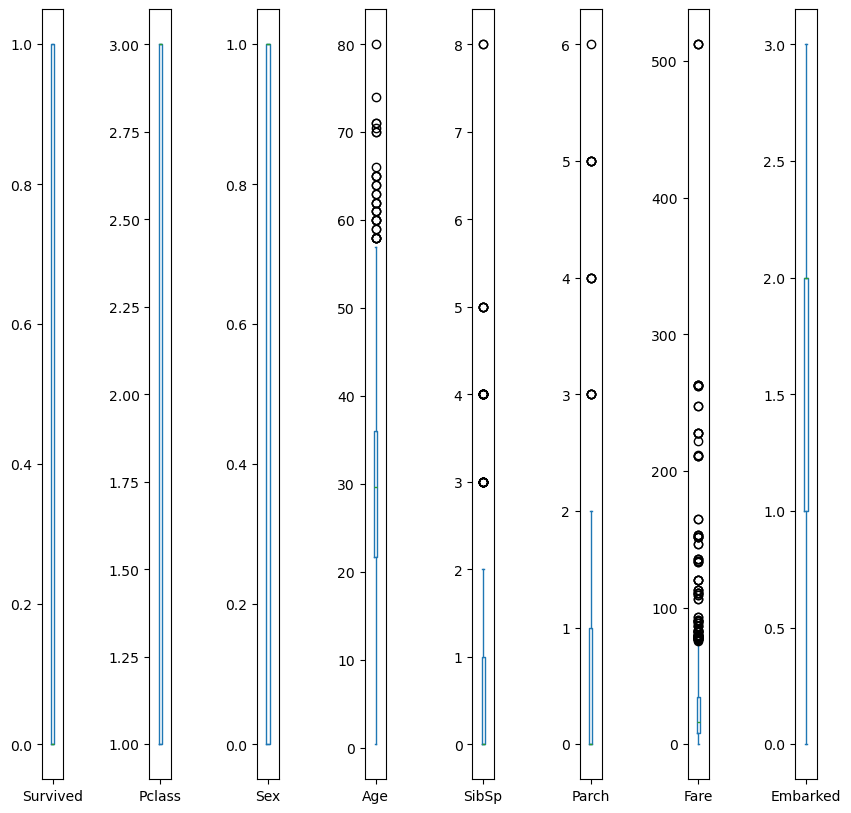

In [105]:
df.plot(kind="box",subplots=True,sharey=False,figsize=(10,10))
plt.subplots_adjust(wspace=4)
plt.show()

#### 6.2) Winsorization (IQR Method)

In [111]:
def winsorize_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return column.clip(lower, upper)

df['Fare'] = winsorize_iqr(df['Fare'])
df['Age'] = winsorize_iqr(df['Age'])

#### 6.3) Verify again using Boxplot 

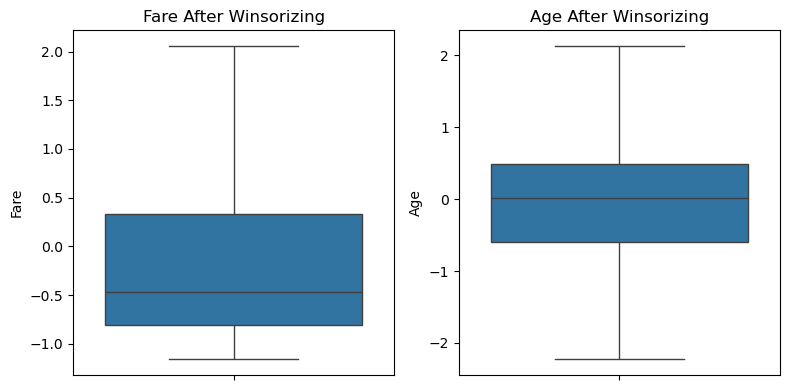

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.boxplot(y=df['Fare'])
plt.title("Fare After Winsorizing")

plt.subplot(1,2,2)
sns.boxplot(y=df['Age'])
plt.title("Age After Winsorizing")

plt.tight_layout()
plt.show()

### Step-7 : Encoding categorical variables

In [119]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Embarked'] = le.fit_transform(df['Embarked'])

### Step-8 : Feature Scaling (Standarization)

In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age','Fare','SibSp','Parch']] = scaler.fit_transform(
    df[['Age','Fare','SibSp','Parch']]
)

### Step-9 : Correlation Analysis

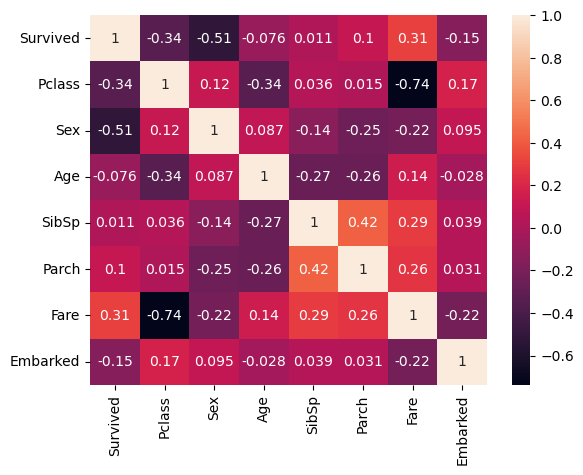

In [118]:
## Using Heatmap
sns.heatmap(df.corr(), annot=True)
plt.show()